# Judul Proyek	: Pemetaan Potensi Diversifikasi Bahan Pangan Berbasis Machine Learning dan Geospasial untuk Optimalisasi Ekspor dan Ketahanan Ekonomi Pulau Jawa

## Deskripsi Proyek

Fakultas		: Fakultas Sains, Teknologi, dan Matematika
Tema			: Talenta Sains Data Berdampak: Mengolah Data,  Menggerakkan Bangsa menuju Indonesia Emas 2045
Sub Tema		: Ketahanan Pangan Berbasis Data (Diversifikasi bahan pangan)
Fokus Proyek	: Pemanfaatan data untuk meningkatkan produksi, distribusi, dan stabilitas pangan nasional
Metode		    : Machine Learning dan Geospasial
Ide			    : Dikarenakan keanekaragaman/diversifikasi bahan pangan untuk ketahanan pangan, maka perlu meningkatkan ekonomi di setiap daerah/provinsi 
Faktor Ketahanan Pangan	: 1) Ketersediaan pangan merujuk pada jumlah, mutu, dan keragaman pangan yang memadai di suatu wilayah, 2) Akses pangan, 3) Stabilitas pangan mengukur kemampuan masyarakat dalam mengakses dan mendapatkan pangan secara terus-menerus 
Target		: 1) Ekspor bahan pangan, 2) Proyek MBG, 3) Kebutuhan Primer

## 1. Persiapan dan Instalasi Library

In [6]:
# Library untuk data manipulation
import pandas as pd
import numpy as np

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library untuk preprocessing dan machine learning
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Library untuk time series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

# Library untuk handling file
import os
import warnings
warnings.filterwarnings('ignore')

## 2. Loading Data Ekspor

In [18]:
# Path file data ekspor
file_ekspor_nilai = 'https://docs.google.com/spreadsheets/d/1OmsoM4OaU6j596EZw5VRZapQkHFp2Uss/export?format=xlsx'
file_ekspor_berat = 'https://docs.google.com/spreadsheets/d/1VoDJY3XtDN6fWSd77eau0c0Jv7RPgpqN/export?format=xlsx'

# Loading data nilai ekspor
df_ekspor_nilai = pd.read_excel(file_ekspor_nilai, skiprows=3)

# Loading data berat ekspor
df_ekspor_berat = pd.read_excel(file_ekspor_berat, skiprows=3)

print("Data Nilai Ekspor:")
display(df_ekspor_nilai.head())
print("\nShape:", df_ekspor_nilai.shape)

print("\nData Berat Ekspor:")
display(df_ekspor_berat.head())
print("\nShape:", df_ekspor_berat.shape)

Data Nilai Ekspor:


,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,Sayur-sayuran,4.5,9.9,7.0,29.0,49.4,51.5,27.7,17.0,25.3,16.1,10.8,6.7,254.9
1,Tembakau,2.2,4.6,9.5,2.7,2.6,5.7,14.4,10.8,6.8,6.4,7.4,5.7,78.8
2,Jagung,0.4,0.4,0.1,0.1,0.1,2.6,0.8,0.1,0.1,0.1,0.2,0.1,5.1
3,Kopi,168.9,184.5,200.8,152.1,208.2,219.3,208.6,255.2,270.3,248.5,210.1,175.4,2501.9
4,"Tanaman Obat, Aromatik, dan Rempah-Rempah",33.9,38.5,63.1,46.8,67.5,58.3,62.9,56.0,56.6,60.2,50.8,47.7,642.3



Shape: (15, 14)

Data Berat Ekspor:


,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,Sayur-sayuran,4.1,4.4,3.9,6.9,10.4,12.8,9.5,14.8,16.0,13.4,10.5,6.4,113.1
1,Tembakau,0.1,0.4,0.6,0.2,0.3,0.7,1.1,1.1,0.6,0.6,0.5,0.4,6.6
2,Jagung,0.1,0.2,0.1,0.1,0.1,6.4,0.3,0.1,0.1,0.1,0.1,0.1,7.8
3,Kopi,30.4,33.7,35.5,26.7,37.5,42.9,43.5,61.1,61.5,53.5,45.3,37.3,508.9
4,"Tanaman Obat, Aromatik, dan Rempah-Rempah",17.2,18.3,31.0,24.2,33.6,26.4,32.5,28.5,29.5,27.6,22.9,20.6,312.3



Shape: (15, 14)


## 3. Loading Data SDA (Pertanian)

In [24]:
# Path file data SDA
file_produksi_padi = 'https://docs.google.com/spreadsheets/d/1DoXPBl1A40odYFCBORBr3FF4bk2YgBwl/export?format=xlsx'
file_luas_panen_padi = 'https://docs.google.com/spreadsheets/d/1qD99-HpB4t6r0Sab-aAv4BXzQlQjPsQ3/export?format=xlsx'
file_produksi_sayuran = 'https://docs.google.com/spreadsheets/d/1mZXFcwLP8tE0UJw8TFTTOPIALS2HE6fa/export?format=xlsx'
file_luas_panen_sayuran = 'https://docs.google.com/spreadsheets/d/1y1uhTZrKbcKxogF4yCJjeSA5KQ-PXdYO/export?format=xlsx'

# Loading data produksi padi (skip header)
df_produksi_padi = pd.read_excel(file_produksi_padi, skiprows=3)

# Loading data luas panen padi (skip header)
df_luas_panen_padi = pd.read_excel(file_luas_panen_padi, skiprows=3)

# Loading data produksi sayuran
df_produksi_sayuran = pd.read_excel(file_produksi_sayuran)

# Loading data luas panen sayuran
df_luas_panen_sayuran = pd.read_excel(file_luas_panen_sayuran)

print("Data Produksi Padi:")
display(df_produksi_padi.head())
print("\nShape:", df_produksi_padi.shape)

print("\nData Luas Panen Padi:")
display(df_luas_panen_padi.head())
print("\nShape:", df_luas_panen_padi.shape)

print("\nData Produksi Sayuran:")
display(df_produksi_sayuran.head())
print("\nShape:", df_produksi_sayuran.shape)

print("\nData Luas Panen Sayuran:")
display(df_luas_panen_sayuran.head())
print("\nShape:", df_luas_panen_sayuran.shape)

Data Produksi Padi:


,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,ACEH,71061.29,105254.72,294608.47,281119.38,159158.95,62726.81,12074.69,93899.42,191958.11,225174.64,53601.03,64562.57,1615200.08
1,SUMATERA UTARA,194014.90,404718.92,314988.21,179663.78,199994.75,246094.52,173992.50,277021.17,346982.65,200960.40,109865.22,104358.33,2752655.35
2,SUMATERA BARAT,141426.58,157807.91,162064.93,98223.19,109132.17,131014.43,92412.45,85163.51,150659.50,95787.41,67092.35,91912.25,1382696.68
3,RIAU,15184.25,26669.73,43973.22,17391.92,16280.87,19302.66,10277.69,15284.53,28688.69,20822.28,10245.85,7949.58,232071.27
4,JAMBI,27546.67,26998.74,34681.74,32435.29,28690.84,44505.77,17471.96,34216.32,54880.08,32671.37,18349.91,15342.31,367791.00



Shape: (39, 14)

Data Luas Panen Padi:


,Unnamed: 0,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
0,ACEH,13865.52,19182.13,51639.22,48258.22,28268.68,11499.55,2206.68,16743.13,32261.50,38641.97,9338.54,11276.88,283182.01
1,SUMATERA UTARA,39636.92,82756.41,59725.29,33441.18,40633.32,49224.88,34184.77,52843.26,64702.20,36042.26,20742.08,21076.63,535009.20
2,SUMATERA BARAT,28406.64,32279.74,32645.05,19828.25,23601.95,28290.36,19673.19,18763.49,30595.71,18733.28,13153.52,18104.41,284075.59
3,RIAU,3679.52,7002.31,10976.51,4368.83,5208.01,6179.77,3290.07,4738.89,6002.01,4149.96,2189.96,1716.26,59502.09
4,JAMBI,5738.99,6258.40,7587.65,6919.21,5820.21,9148.44,3617.54,7402.07,12725.97,7893.96,3862.81,3397.91,80373.17



Shape: (39, 14)

Data Produksi Sayuran:


,Provinsi,Produksi Bawang Daun (kuintal) (Kw),Produksi Bawang Merah (kuintal) (Kw),Produksi Bawang Putih (kuintal) (Kw),Produksi Bayam (kuintal) (Kw),Produksi Buncis (kuintal) (Kw),Produksi Cabai Rawit (kuintal) (Kw),Produksi Kacang Panjang (kuintal) (Kw),Produksi Kangkung (kuintal) (Kw),Produksi Kembang Kol (kuintal) (Kw),...,Produksi Semangka (kuintal) (Kw),Produksi Stroberi (kuintal) (Kw),Produksi Terung (kuintal) (Kw),Produksi Tomat (kuintal) (Kw),Produksi Wortel (kuintal) (Kw),Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),Produksi Cabai Keriting(kuintal) (Kw),Produksi Jamur Tiram (kuintal) (Kw),Produksi Jamur Merang (kuintal) (Kw),Produksi Jamur Lainnya (kuintal) (Kw)
0,Aceh,6875.6,132815.50,-,50403.72,2118,1123021.44,136742.42,75861.45,4501,...,78774.5,263,94845.51,102112.30,446,1292.5,1840950.24,22.01,15.76,0.2
1,Sumatera Utara,200160.06,520953.05,430.6,163510.59,620268.1,1090525.07,255779.61,225715.05,649340.98,...,222227.82,1630.53,893049.63,2345798.56,1987470.92,29735.47,2119003.08,1034.5,-,4.1
2,Sumatera Barat,684950.84,2328953.97,5989.65,72149.30,531262.87,314907.30,143912.44,78734.45,103752.35,...,91748,1134.57,1053179.59,1011176.96,279305.25,-,1217572.91,1614.64,-,-
3,Riau,200.4,400.41,-,74143.04,27.1,66824.69,80163.60,107633.48,0.05,...,184287.17,-,57943.30,1682.65,-,12082.26,67879.40,4456.35,-,605
4,Jambi,122874,218558.98,-,43567.01,66754.3,421738.75,62983.69,58356.20,114194,...,64938.49,86.82,337685.51,1002814.08,170665,6535,2139753.27,1232.25,-,-



Shape: (39, 27)

Data Luas Panen Sayuran:


,Provinsi,Luas Panen Bawang Daun (hektar) (Ha),Luas Panen Bawang Merah (hektar) (Ha),Luas Panen Bawang Putih (hektar) (Ha),Luas Panen Bayam (hektar) (Ha),Luas Panen Buncis (hektar) (Ha),Luas Panen Cabai Rawit (hektar) (Ha),Luas Panen Kacang Panjang (hektar) (Ha),Luas Panen Kangkung (hektar) (Ha),Luas Panen Kembang Kol (hektar) (Ha),...,Luas Panen Semangka (hektar) (Ha),Luas Panen Stroberi (hektar) (Ha),Luas Panen Terung (hektar) (Ha),Luas Panen Tomat (hektar) (Ha),Luas Panen Wortel (hektar) (Ha),Luas Panen Cabai Besar/TW/Teropong (hektar) (Ha),Luas Panen Cabai Keriting (hektar) (Ha),Luas Panen Jamur tiram (meter persegi) (Ha),Luas Panen Jamur Merang (meter persegi) (M2),Luas Panen Jamur Lainnya (meter persegi) (M2)
0,Aceh,179.94,1237.27,-,1597.08,66.25,7165.87,1320.13,1501.62,137.18,...,787.66,13,871.43,690.49,26.5,47.82,10286.94,87.6,97.5,0.5
1,Sumatera Utara,2151.61,3447.16,10.8,2565.81,2763.56,9886.21,1970.96,2802.53,3609.41,...,1800.39,29.3,3630.60,6164.60,9378.3,202.72,16169.10,16320,-,200
2,Sumatera Barat,5542.18,15192.59,54.6,1604.67,3819.24,3526.20,1338.91,1691.77,1074.48,...,564.15,68.63,5473.56,3914.16,1453.55,-,9411.40,2322.5,-,-
3,Riau,3.66,6.78,-,2044.97,12.5,1039.26,1122.55,2225.02,0.02,...,1815.21,-,773.86,45.53,-,175.72,895.90,21747.17,-,710
4,Jambi,775.28,1983.32,-,1050.91,406.27,1363.24,886.86,1202.21,610,...,547.77,4.21,1040.55,1161.33,1080,138.1,6195.30,4611,-,-



Shape: (39, 27)


## 4. Filtering Data Provinsi Pulau Jawa

In [25]:
# List provinsi Pulau Jawa
provinsi_jawa = ['BANTEN', 'DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR']

# Data Produksi Padi
df_produksi_padi = df_produksi_padi.rename(columns={df_produksi_padi.columns[0]: 'Provinsi'})

# Data Luas Panen Padi
df_luas_panen_padi = df_luas_panen_padi.rename(columns={df_luas_panen_padi.columns[0]: 'Provinsi'})

print("Kolom Produksi Padi:", df_produksi_padi.columns.tolist()[:5], "...")
print("Shape Produksi Padi:", df_produksi_padi.shape)

# Data Produksi Sayuran
df_produksi_sayuran = df_produksi_sayuran.rename(columns={df_produksi_sayuran.columns[0]: 'Provinsi'})

# Data Luas Panen Sayuran
df_luas_panen_sayuran = df_luas_panen_sayuran.rename(columns={df_luas_panen_sayuran.columns[0]: 'Provinsi'})

print("Kolom Produksi Sayuran:", df_produksi_sayuran.columns.tolist()[:10], "...")
print("Shape Produksi Sayuran:", df_produksi_sayuran.shape)

# FILTER DATA PROVINSI JAWA
def filter_provinsi_jawa(df, nama_data):
    """
    Filter dataframe hanya untuk provinsi Pulau Jawa
    """
    df_filtered = df[df['Provinsi'].str.upper().isin(provinsi_jawa)].copy()
    print(f"{nama_data}: {len(df_filtered)} provinsi Jawa ditemukan")
    return df_filtered

# Filter semua data
df_produksi_padi_jawa = filter_provinsi_jawa(df_produksi_padi, 'Produksi Padi')
df_luas_panen_padi_jawa = filter_provinsi_jawa(df_luas_panen_padi, 'Luas Panen Padi')
df_produksi_sayuran_jawa = filter_provinsi_jawa(df_produksi_sayuran, 'Produksi Sayuran')
df_luas_panen_sayuran_jawa = filter_provinsi_jawa(df_luas_panen_sayuran, 'Luas Panen Sayuran')

# Tampilkan preview
print("\nProduksi Padi:")
display(df_produksi_padi_jawa)

print("\nLuas Panen Padi:")
display(df_luas_panen_padi_jawa)

print("\nProduksi Sayuran:")
display(df_produksi_sayuran_jawa)

print("\nLuas Panen Sayuran:")
display(df_luas_panen_sayuran_jawa)

Kolom Produksi Padi: ['Provinsi', 'Januari', 'Februari', 'Maret', 'April'] ...
Shape Produksi Padi: (39, 14)
Kolom Produksi Sayuran: ['Provinsi', 'Produksi Bawang Daun (kuintal) (Kw)', 'Produksi Bawang Merah (kuintal) (Kw)', 'Produksi Bawang Putih (kuintal) (Kw)', 'Produksi Bayam (kuintal) (Kw)', 'Produksi Buncis (kuintal) (Kw)', 'Produksi Cabai Rawit (kuintal) (Kw)', 'Produksi Kacang Panjang (kuintal) (Kw)', 'Produksi Kangkung (kuintal) (Kw)', 'Produksi Kembang Kol (kuintal) (Kw)'] ...
Shape Produksi Sayuran: (39, 27)
Produksi Padi: 6 provinsi Jawa ditemukan
Luas Panen Padi: 6 provinsi Jawa ditemukan
Produksi Sayuran: 6 provinsi Jawa ditemukan
Luas Panen Sayuran: 6 provinsi Jawa ditemukan

Produksi Padi:


,Provinsi,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
10,DKI JAKARTA,112.87,0.00,0.00,16.94,60.76,19.78,73.28,524.11,392.62,192.90,70.00,24.19,1487.45
11,JAWA BARAT,362854.42,445035.71,1219278.69,1313909.97,1101292.03,716294.78,1032170.75,935039.53,736020.21,969970.57,839212.84,555574.25,10226653.75
12,JAWA TENGAH,194648.97,798789.24,1948745.59,1268755.61,474734.76,790385.24,1073061.21,824745.45,663616.59,530157.41,410189.06,326233.71,9304062.84
13,DI YOGYAKARTA,35465.86,120952.63,90075.92,54072.56,30314.74,65598.60,43050.37,38641.79,14731.58,19535.08,19298.89,15772.08,547510.10
14,JAWA TIMUR,384669.75,573704.28,2041229.45,1818524.03,695167.62,779086.12,1012403.21,824728.65,657164.84,588918.90,582236.25,480527.48,10438360.58
15,BANTEN,20822.20,138714.14,398689.80,296544.83,63718.93,59061.13,206875.23,257750.35,178194.84,80854.72,35765.89,37024.81,1774016.87



Luas Panen Padi:


,Provinsi,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
10,DKI JAKARTA,24.39,0.00,0.00,3.60,11.60,3.78,13.47,98.25,68.47,33.61,12.15,4.22,273.54
11,JAWA BARAT,62186.39,76932.74,209730.96,222637.25,188434.06,127431.93,186298.94,167966.42,124308.36,157701.27,137610.10,94061.79,1755300.23
12,JAWA TENGAH,34906.46,137299.91,335096.11,223138.01,94298.71,150616.49,207054.24,161730.89,116088.47,87508.52,70299.22,56957.10,1674994.11
13,DI YOGYAKARTA,6303.13,24454.65,17209.30,9740.25,6271.12,13822.07,8724.00,7667.15,2754.70,3714.27,3687.99,2875.60,107224.23
14,JAWA TIMUR,66160.11,101085.09,358236.41,314484.44,125787.47,146236.90,189024.64,152167.32,109558.85,99078.30,98413.91,81112.85,1841346.29
15,BANTEN,3759.02,25688.22,71996.91,54716.02,13186.40,12298.59,43728.17,53761.46,35683.30,16064.32,7152.36,7385.77,345420.55



Produksi Sayuran:


,Provinsi,Produksi Bawang Daun (kuintal) (Kw),Produksi Bawang Merah (kuintal) (Kw),Produksi Bawang Putih (kuintal) (Kw),Produksi Bayam (kuintal) (Kw),Produksi Buncis (kuintal) (Kw),Produksi Cabai Rawit (kuintal) (Kw),Produksi Kacang Panjang (kuintal) (Kw),Produksi Kangkung (kuintal) (Kw),Produksi Kembang Kol (kuintal) (Kw),...,Produksi Semangka (kuintal) (Kw),Produksi Stroberi (kuintal) (Kw),Produksi Terung (kuintal) (Kw),Produksi Tomat (kuintal) (Kw),Produksi Wortel (kuintal) (Kw),Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),Produksi Cabai Keriting(kuintal) (Kw),Produksi Jamur Tiram (kuintal) (Kw),Produksi Jamur Merang (kuintal) (Kw),Produksi Jamur Lainnya (kuintal) (Kw)
10,DKI Jakarta,-,52.73,-,24522.03,-,421.93,0.23,31918.84,471.47,...,-,-,528.39,29.97,-,0.32,0.66,-,-,-
11,Jawa Barat,1567095.63,1994154.01,2618,372798.98,752802.1,1987916.59,666031.83,683886.87,306363.65,...,48382.8,417185.5,1188275.45,2684310.69,842028,1372168.21,2217330.71,115058.99,20656.69,3310.6
12,Jawa Tengah,1231901.43,5840345.01,235421.12,161035.00,330468.15,2663050.62,181843.57,345352.28,264143.3,...,462618.1,4296.99,576275.90,1130126.19,1339669.5,501228.63,1673982.71,83741.98,373.9,7091.91
13,DI Yogyakarta,3301.5,267186.01,-,31826.38,1518.6,250299.13,17371.14,58719.00,557.22,...,43666.11,17.65,28246.81,6677.60,-,28075.18,451717.72,18850.58,266.9,120.9
14,Jawa Timur,1159377.98,5003012.27,3243.08,148956.38,262748.41,6037178.26,312706.03,331999.52,288950.9,...,1131047.85,5789.14,941809.95,1268102.30,892135.58,1045356.44,356646.68,128641.99,1729.68,1728.24
15,Banten,2013.6,13950.76,-,76425.13,436.3,76213.37,40099.30,105529.12,-,...,8245,-,16435.72,4963.71,1350,3213.32,75215.63,1079.17,2,260



Luas Panen Sayuran:


,Provinsi,Luas Panen Bawang Daun (hektar) (Ha),Luas Panen Bawang Merah (hektar) (Ha),Luas Panen Bawang Putih (hektar) (Ha),Luas Panen Bayam (hektar) (Ha),Luas Panen Buncis (hektar) (Ha),Luas Panen Cabai Rawit (hektar) (Ha),Luas Panen Kacang Panjang (hektar) (Ha),Luas Panen Kangkung (hektar) (Ha),Luas Panen Kembang Kol (hektar) (Ha),...,Luas Panen Semangka (hektar) (Ha),Luas Panen Stroberi (hektar) (Ha),Luas Panen Terung (hektar) (Ha),Luas Panen Tomat (hektar) (Ha),Luas Panen Wortel (hektar) (Ha),Luas Panen Cabai Besar/TW/Teropong (hektar) (Ha),Luas Panen Cabai Keriting (hektar) (Ha),Luas Panen Jamur tiram (meter persegi) (Ha),Luas Panen Jamur Merang (meter persegi) (M2),Luas Panen Jamur Lainnya (meter persegi) (M2)
10,DKI Jakarta,-,3.24,-,403.12,-,17.94,0.04,474.56,3.61,...,-,-,7.32,5.12,-,0.02,0.23,-,-,-
11,Jawa Barat,12068.33,16766.65,45.05,5488.20,4375.26,13718.08,4653.83,7424.04,2189.03,...,398.79,525.5,4730.40,9674.42,5037.23,9540.21,14166.62,964318.92,360269.6,5300
12,Jawa Tengah,11962.72,48607.36,3252.51,2866.65,2936.34,30270.65,2540.53,3631.29,3330.7,...,2821.24,59.69,4132.92,5614.20,7462.5,5654.66,19237.74,559102.42,4585,79566.5
13,DI Yogyakarta,33.5,2593.50,-,397.13,9.2,2329.38,185.08,481.83,3.9,...,375.62,0.41,209.12,70.67,-,321,2925.53,31493.42,1750,100
14,Jawa Timur,9663.62,53105.19,57.04,2386.85,2111.43,85759.00,3078.57,5542.70,1991.45,...,5989.43,2168.68,4218.33,5401.00,4499.17,9995.93,4204.83,310589.13,19920.6,2091.84
15,Banten,27.4,201.70,-,2070.28,8.3,830.19,493.66,2246.02,-,...,68.1,-,161.99,42.11,14,67.98,823.20,3582.99,100,100


## 5. Preprocessing Data - Pengecekan Missing Values

In [34]:
def cek_missing_values(df, nama_df):
    """
    Fungsi untuk mengecek missing values dalam dataframe
    """
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Kolom': missing.index,
        'Missing Values': missing.values,
        'Persentase (%)': missing_percent.values
    })
    
    print(f"\nMissing Values pada {nama_df}:")
    print(missing_df[missing_df['Missing Values'] > 0])
    print(f"Total missing values: {missing.sum()}")
    
    return missing_df

## 6. Preprocessing Data - Handling Missing Values

In [35]:
def drop_columns_with_minus(df, nama_df):
    """
    Menghapus kolom yang mengandung tanda '-' (meskipun hanya 1)
    """
    df_clean = df.copy()
    cols_to_drop = []
    
    for col in df_clean.columns:
        if col != 'Provinsi':
            # Cek apakah ada tanda '-' di kolom ini
            has_minus = df_clean[col].astype(str).str.contains('-', na=False).any()
            if has_minus:
                cols_to_drop.append(col)
    
    # Hapus kolom
    df_clean = df_clean.drop(columns=cols_to_drop)
    
    print(f"{nama_df}: Dihapus {len(cols_to_drop)} kolom yang mengandung '-'")
    print(f"Kolom yang dihapus: {cols_to_drop}")
    print(f"Sisa kolom: {df_clean.shape[1]} kolom")
    
    return df_clean, cols_to_drop

# Hapus kolom yang mengandung tanda '-'
df_produksi_padi_clean, drop1 = drop_columns_with_minus(df_produksi_padi_jawa, 'Produksi Padi')
df_luas_panen_padi_clean, drop2 = drop_columns_with_minus(df_luas_panen_padi_jawa, 'Luas Panen Padi')
df_produksi_sayuran_clean, drop3 = drop_columns_with_minus(df_produksi_sayuran_jawa, 'Produksi Sayuran')
df_luas_panen_sayuran_clean, drop4 = drop_columns_with_minus(df_luas_panen_sayuran_jawa, 'Luas Panen Sayuran')

print("\nProduksi Padi (Clean):")
display(df_produksi_padi_clean)

print("\nLuas Panen Padi (Clean):")
display(df_luas_panen_padi_clean)

print("\nProduksi Sayuran (Clean):")
display(df_produksi_sayuran_clean)

print("\nLuas Panen Sayuran (Clean):")
display(df_luas_panen_sayuran_clean)

Produksi Padi: Dihapus 0 kolom yang mengandung '-'
Kolom yang dihapus: []
Sisa kolom: 14 kolom
Luas Panen Padi: Dihapus 0 kolom yang mengandung '-'
Kolom yang dihapus: []
Sisa kolom: 14 kolom
Produksi Sayuran: Dihapus 14 kolom yang mengandung '-'
Kolom yang dihapus: ['Produksi Bawang Daun (kuintal) (Kw)', 'Produksi Bawang Putih (kuintal) (Kw)', 'Produksi Buncis (kuintal) (Kw)', 'Produksi Kembang Kol (kuintal) (Kw)', 'Produksi Kentang (kuintal) (Kw)', 'Produksi Ketimun (kuintal) (Kw)', 'Produksi Kubis (kuintal) (Kw)', 'Produksi Paprika (kuintal) (Kw)', 'Produksi Semangka (kuintal) (Kw)', 'Produksi Stroberi (kuintal) (Kw)', 'Produksi Wortel (kuintal) (Kw)', 'Produksi Jamur Tiram (kuintal) (Kw)', 'Produksi Jamur Merang (kuintal) (Kw)', 'Produksi Jamur Lainnya (kuintal) (Kw)']
Sisa kolom: 13 kolom
Luas Panen Sayuran: Dihapus 14 kolom yang mengandung '-'
Kolom yang dihapus: ['Luas Panen Bawang Daun (hektar) (Ha)', 'Luas Panen Bawang Putih (hektar) (Ha)', 'Luas Panen Buncis (hektar) (Ha)', '

,Provinsi,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
10,DKI JAKARTA,112.87,0.00,0.00,16.94,60.76,19.78,73.28,524.11,392.62,192.90,70.00,24.19,1487.45
11,JAWA BARAT,362854.42,445035.71,1219278.69,1313909.97,1101292.03,716294.78,1032170.75,935039.53,736020.21,969970.57,839212.84,555574.25,10226653.75
12,JAWA TENGAH,194648.97,798789.24,1948745.59,1268755.61,474734.76,790385.24,1073061.21,824745.45,663616.59,530157.41,410189.06,326233.71,9304062.84
13,DI YOGYAKARTA,35465.86,120952.63,90075.92,54072.56,30314.74,65598.60,43050.37,38641.79,14731.58,19535.08,19298.89,15772.08,547510.10
14,JAWA TIMUR,384669.75,573704.28,2041229.45,1818524.03,695167.62,779086.12,1012403.21,824728.65,657164.84,588918.90,582236.25,480527.48,10438360.58
15,BANTEN,20822.20,138714.14,398689.80,296544.83,63718.93,59061.13,206875.23,257750.35,178194.84,80854.72,35765.89,37024.81,1774016.87



Luas Panen Padi (Clean):


,Provinsi,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember,Tahunan
10,DKI JAKARTA,24.39,0.00,0.00,3.60,11.60,3.78,13.47,98.25,68.47,33.61,12.15,4.22,273.54
11,JAWA BARAT,62186.39,76932.74,209730.96,222637.25,188434.06,127431.93,186298.94,167966.42,124308.36,157701.27,137610.10,94061.79,1755300.23
12,JAWA TENGAH,34906.46,137299.91,335096.11,223138.01,94298.71,150616.49,207054.24,161730.89,116088.47,87508.52,70299.22,56957.10,1674994.11
13,DI YOGYAKARTA,6303.13,24454.65,17209.30,9740.25,6271.12,13822.07,8724.00,7667.15,2754.70,3714.27,3687.99,2875.60,107224.23
14,JAWA TIMUR,66160.11,101085.09,358236.41,314484.44,125787.47,146236.90,189024.64,152167.32,109558.85,99078.30,98413.91,81112.85,1841346.29
15,BANTEN,3759.02,25688.22,71996.91,54716.02,13186.40,12298.59,43728.17,53761.46,35683.30,16064.32,7152.36,7385.77,345420.55



Produksi Sayuran (Clean):


,Provinsi,Produksi Bawang Merah (kuintal) (Kw),Produksi Bayam (kuintal) (Kw),Produksi Cabai Rawit (kuintal) (Kw),Produksi Kacang Panjang (kuintal) (Kw),Produksi Kangkung (kuintal) (Kw),Produksi Labu Siam (kuintal) (Kw),Produksi Melon (kuintal) (Kw),Produksi Petsai/Sawi (kuintal) (Kw),Produksi Terung (kuintal) (Kw),Produksi Tomat (kuintal) (Kw),Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),Produksi Cabai Keriting(kuintal) (Kw)
10,DKI Jakarta,52.73,24522.03,421.93,0.23,31918.84,64,7.9,19158.71,528.39,29.97,0.32,0.66
11,Jawa Barat,1994154.01,372798.98,1987916.59,666031.83,683886.87,910961.36,10804.07,1498030.17,1188275.45,2684310.69,1372168.21,2217330.71
12,Jawa Tengah,5840345.01,161035.00,2663050.62,181843.57,345352.28,1034344.6,220861.69,971342.68,576275.90,1130126.19,501228.63,1673982.71
13,DI Yogyakarta,267186.01,31826.38,250299.13,17371.14,58719.00,200.05,66638.7,33900.58,28246.81,6677.60,28075.18,451717.72
14,Jawa Timur,5003012.27,148956.38,6037178.26,312706.03,331999.52,788540.88,605492.8,833208.09,941809.95,1268102.30,1045356.44,356646.68
15,Banten,13950.76,76425.13,76213.37,40099.30,105529.12,1130.5,2576.6,86815.48,16435.72,4963.71,3213.32,75215.63



Luas Panen Sayuran (Clean):


,Provinsi,Luas Panen Bawang Merah (hektar) (Ha),Luas Panen Bayam (hektar) (Ha),Luas Panen Cabai Rawit (hektar) (Ha),Luas Panen Kacang Panjang (hektar) (Ha),Luas Panen Kangkung (hektar) (Ha),Luas Panen Labu Siam (hektar) (Ha),Luas Panen Melon (hektar) (Ha),Luas Panen Petsai/Sawi (hektar) (Ha),Luas Panen Terung (hektar) (Ha),Luas Panen Tomat (hektar) (Ha),Luas Panen Cabai Besar/TW/Teropong (hektar) (Ha),Luas Panen Cabai Keriting (hektar) (Ha)
10,DKI Jakarta,3.24,403.12,17.94,0.04,474.56,1.1,1.23,326.72,7.32,5.12,0.02,0.23
11,Jawa Barat,16766.65,5488.20,13718.08,4653.83,7424.04,2286.32,115.1,11321.17,4730.40,9674.42,9540.21,14166.62
12,Jawa Tengah,48607.36,2866.65,30270.65,2540.53,3631.29,1072.81,1492.1,10100.18,4132.92,5614.20,5654.66,19237.74
13,DI Yogyakarta,2593.50,397.13,2329.38,185.08,481.83,2.2,620.59,422.35,209.12,70.67,321,2925.53
14,Jawa Timur,53105.19,2386.85,85759.00,3078.57,5542.70,1522.02,3398.13,7104.93,4218.33,5401.00,9995.93,4204.83
15,Banten,201.70,2070.28,830.19,493.66,2246.02,9.2,15.6,1643.39,161.99,42.11,67.98,823.20


## 7. Data Reshaping - Melting Data

In [36]:
def melt_data_bulan(df, id_vars='Provinsi', value_name='Nilai'):
    """
    Mengubah data dari format lebar (bulan sebagai kolom) ke format panjang
    """
    # Ambil kolom bulan
    bulan_cols = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
                  'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
    
    # Pastikan kolom yang di-melt hanya bulan yang ada
    cols_to_melt = [col for col in bulan_cols if col in df.columns]
    
    # Tambahkan kolom Tahunan jika ada
    if 'Tahunan' in df.columns:
        df = df.drop(columns=['Tahunan'])
    
    # Melting data
    df_melted = pd.melt(
        df, 
        id_vars=id_vars,
        value_vars=cols_to_melt,
        var_name='Bulan',
        value_name=value_name
    )
    
    # Mapping nama bulan ke angka
    bulan_map = {
        'Januari': 1, 'Februari': 2, 'Maret': 3, 'April': 4,
        'Mei': 5, 'Juni': 6, 'Juli': 7, 'Agustus': 8,
        'September': 9, 'Oktober': 10, 'November': 11, 'Desember': 12
    }
    df_melted['Bulan_Num'] = df_melted['Bulan'].map(bulan_map)
    
    return df_melted

# Melt data produksi padi
df_produksi_padi_melted = melt_data_bulan(df_produksi_padi_clean, 'Provinsi', 'Produksi_Padi_Ton')
df_luas_panen_padi_melted = melt_data_bulan(df_luas_panen_padi_clean, 'Provinsi', 'Luas_Panen_Ha')

print("Data Produksi Padi - Format Panjang:")
display(df_produksi_padi_melted.head())
print("\nData Luas Panen Padi - Format Panjang:")
display(df_luas_panen_padi_melted.head())

Data Produksi Padi - Format Panjang:


,Provinsi,Bulan,Produksi_Padi_Ton,Bulan_Num
0,DKI JAKARTA,Januari,112.87,1
1,JAWA BARAT,Januari,362854.42,1
2,JAWA TENGAH,Januari,194648.97,1
3,DI YOGYAKARTA,Januari,35465.86,1
4,JAWA TIMUR,Januari,384669.75,1



Data Luas Panen Padi - Format Panjang:


,Provinsi,Bulan,Luas_Panen_Ha,Bulan_Num
0,DKI JAKARTA,Januari,24.39,1
1,JAWA BARAT,Januari,62186.39,1
2,JAWA TENGAH,Januari,34906.46,1
3,DI YOGYAKARTA,Januari,6303.13,1
4,JAWA TIMUR,Januari,66160.11,1


## 8. Ekstraksi Data Sayuran Per Provinsi

In [40]:
def extract_komoditas_per_provinsi(df_clean, df_luas_clean):
    """
    Mengekstrak data produksi dan luas panen per komoditas per provinsi
    """
    # Standardisasi nama provinsi di kedua dataframe
    df_prod = df_clean.copy()
    df_luas = df_luas_clean.copy()
    
    # Upper case untuk standardisasi
    df_prod['Provinsi'] = df_prod['Provinsi'].str.upper()
    df_luas['Provinsi'] = df_luas['Provinsi'].str.upper()
    
    # Set index
    df_prod = df_prod.set_index('Provinsi')
    df_luas = df_luas.set_index('Provinsi')
    
    # Filter provinsi Jawa (pakai intersection biar aman)
    prov_available = df_prod.index.intersection(provinsi_jawa)
    
    df_prod_jawa = df_prod.loc[prov_available]
    df_luas_jawa = df_luas.loc[prov_available]
    
    print(f"Provinsi Jawa yang ditemukan: {prov_available.tolist()}")
    
    return df_prod_jawa, df_luas_jawa

def get_komoditas_list(df):
    """
    Mendapatkan daftar komoditas dari dataframe
    """
    # Ambil semua kolom kecuali 'Provinsi'
    return [col for col in df.columns if col != 'Provinsi']

# Ekstrak data sayuran
df_prod_sayuran_jawa, df_luas_sayuran_jawa = extract_komoditas_per_provinsi(
    df_produksi_sayuran_clean, df_luas_panen_sayuran_clean
)

print("\nData Produksi Sayuran per Komoditas (Provinsi Jawa):")
display(df_prod_sayuran_jawa)

print("\nData Luas Panen Sayuran per Komoditas (Provinsi Jawa):")
display(df_luas_sayuran_jawa)

# Dapatkan daftar komoditas
komoditas_list = get_komoditas_list(df_produksi_sayuran_clean)
print(f"\nDaftar Komoditas Sayuran: {komoditas_list}")

Provinsi Jawa yang ditemukan: ['DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR', 'BANTEN']

Data Produksi Sayuran per Komoditas (Provinsi Jawa):


,Produksi Bawang Merah (kuintal) (Kw),Produksi Bayam (kuintal) (Kw),Produksi Cabai Rawit (kuintal) (Kw),Produksi Kacang Panjang (kuintal) (Kw),Produksi Kangkung (kuintal) (Kw),Produksi Labu Siam (kuintal) (Kw),Produksi Melon (kuintal) (Kw),Produksi Petsai/Sawi (kuintal) (Kw),Produksi Terung (kuintal) (Kw),Produksi Tomat (kuintal) (Kw),Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),Produksi Cabai Keriting(kuintal) (Kw)
Provinsi,,,,,,,,,,,,
DKI JAKARTA,52.73,24522.03,421.93,0.23,31918.84,64,7.9,19158.71,528.39,29.97,0.32,0.66
JAWA BARAT,1994154.01,372798.98,1987916.59,666031.83,683886.87,910961.36,10804.07,1498030.17,1188275.45,2684310.69,1372168.21,2217330.71
JAWA TENGAH,5840345.01,161035.00,2663050.62,181843.57,345352.28,1034344.6,220861.69,971342.68,576275.90,1130126.19,501228.63,1673982.71
DI YOGYAKARTA,267186.01,31826.38,250299.13,17371.14,58719.00,200.05,66638.7,33900.58,28246.81,6677.60,28075.18,451717.72
JAWA TIMUR,5003012.27,148956.38,6037178.26,312706.03,331999.52,788540.88,605492.8,833208.09,941809.95,1268102.30,1045356.44,356646.68
BANTEN,13950.76,76425.13,76213.37,40099.30,105529.12,1130.5,2576.6,86815.48,16435.72,4963.71,3213.32,75215.63



Data Luas Panen Sayuran per Komoditas (Provinsi Jawa):


,Luas Panen Bawang Merah (hektar) (Ha),Luas Panen Bayam (hektar) (Ha),Luas Panen Cabai Rawit (hektar) (Ha),Luas Panen Kacang Panjang (hektar) (Ha),Luas Panen Kangkung (hektar) (Ha),Luas Panen Labu Siam (hektar) (Ha),Luas Panen Melon (hektar) (Ha),Luas Panen Petsai/Sawi (hektar) (Ha),Luas Panen Terung (hektar) (Ha),Luas Panen Tomat (hektar) (Ha),Luas Panen Cabai Besar/TW/Teropong (hektar) (Ha),Luas Panen Cabai Keriting (hektar) (Ha)
Provinsi,,,,,,,,,,,,
DKI JAKARTA,3.24,403.12,17.94,0.04,474.56,1.1,1.23,326.72,7.32,5.12,0.02,0.23
JAWA BARAT,16766.65,5488.20,13718.08,4653.83,7424.04,2286.32,115.1,11321.17,4730.40,9674.42,9540.21,14166.62
JAWA TENGAH,48607.36,2866.65,30270.65,2540.53,3631.29,1072.81,1492.1,10100.18,4132.92,5614.20,5654.66,19237.74
DI YOGYAKARTA,2593.50,397.13,2329.38,185.08,481.83,2.2,620.59,422.35,209.12,70.67,321,2925.53
JAWA TIMUR,53105.19,2386.85,85759.00,3078.57,5542.70,1522.02,3398.13,7104.93,4218.33,5401.00,9995.93,4204.83
BANTEN,201.70,2070.28,830.19,493.66,2246.02,9.2,15.6,1643.39,161.99,42.11,67.98,823.20



Daftar Komoditas Sayuran: ['Produksi Bawang Merah (kuintal) (Kw)', 'Produksi Bayam (kuintal) (Kw)', 'Produksi Cabai Rawit (kuintal) (Kw)', 'Produksi Kacang Panjang (kuintal) (Kw)', 'Produksi Kangkung (kuintal) (Kw)', 'Produksi Labu Siam (kuintal) (Kw)', 'Produksi Melon (kuintal) (Kw)', 'Produksi Petsai/Sawi (kuintal) (Kw)', 'Produksi Terung (kuintal) (Kw)', 'Produksi Tomat (kuintal) (Kw)', 'Produksi Cabai Besar/TW/Teropong (kuintal) (Kw)', 'Produksi Cabai Keriting(kuintal) (Kw)']


## 9. Menghitung Produktivitas Padi

Data Padi dengan Produktivitas:


,Provinsi,Bulan,Produksi_Padi_Ton,Bulan_Num,Luas_Panen_Ha,Produktivitas_Ton_per_Ha
0,DKI JAKARTA,Januari,112.87,1,24.39,4.627716
1,JAWA BARAT,Januari,362854.42,1,62186.39,5.834949
2,JAWA TENGAH,Januari,194648.97,1,34906.46,5.576302
3,DI YOGYAKARTA,Januari,35465.86,1,6303.13,5.626706
4,JAWA TIMUR,Januari,384669.75,1,66160.11,5.814225


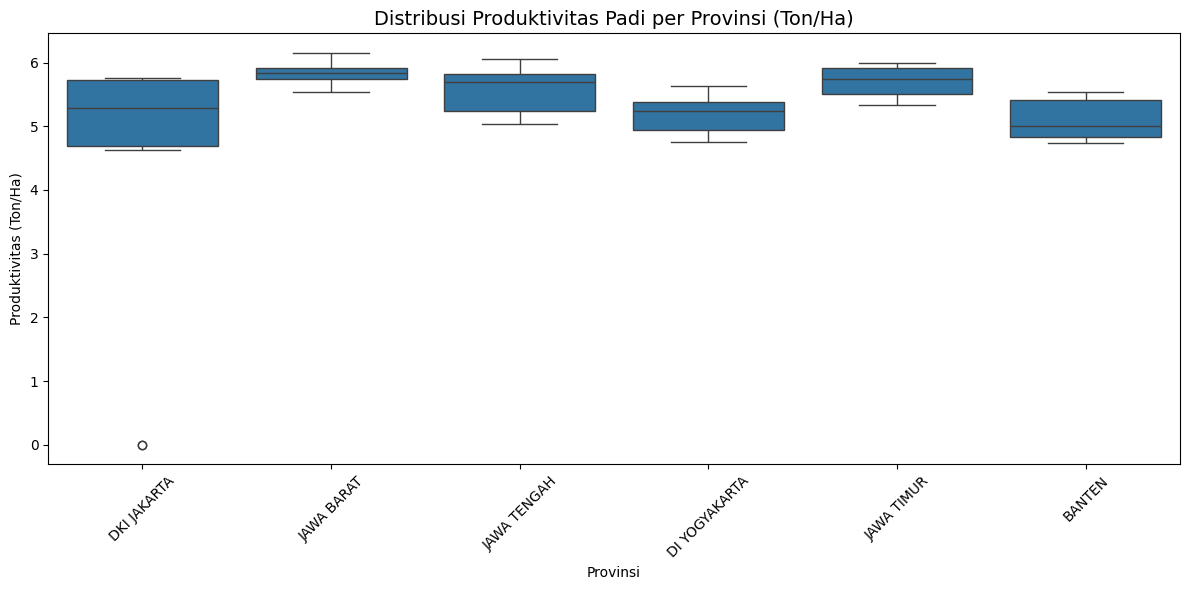

In [41]:
# Menghitung produktivitas padi = produksi / luas panen
# Gabungkan data produksi dan luas panen per provinsi & bulan

# Aggregate data per provinsi
df_padi_aggregate = df_produksi_padi_melted.merge(
    df_luas_panen_padi_melted,
    on=['Provinsi', 'Bulan', 'Bulan_Num'],
    suffixes=('_prod', '_luas')
)

# Hitung produktivitas (Ton/Ha)
df_padi_aggregate['Produktivitas_Ton_per_Ha'] = (
    df_padi_aggregate['Produksi_Padi_Ton'] / df_padi_aggregate['Luas_Panen_Ha']
).replace([np.inf, -np.inf], 0).fillna(0)

print("Data Padi dengan Produktivitas:")
display(df_padi_aggregate.head())

# Visualisasi produktivitas per provinsi
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_padi_aggregate, x='Provinsi', y='Produktivitas_Ton_per_Ha')
plt.title('Distribusi Produktivitas Padi per Provinsi (Ton/Ha)', fontsize=14)
plt.xlabel('Provinsi')
plt.ylabel('Produktivitas (Ton/Ha)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Analisis Ekspor Time Series

Kolom komoditas di df_nilai: 'Komoditas'
Kolom komoditas di df_berat: 'Komoditas'
Komoditas yang dihapus: ['sarang burung', 'lainnya', 'jumlah']

Top 10 Komoditas Ekspor Potensial:


,Komoditas,Nilai_Ekspor_Juta_USD,Berat_Ekspor_Ribu_Ton,Nilai_Per_Ton_Juta_USD
0,Kopi,2501.9,508.9,4.916290
2,Buah-buahan Tahunan,759.8,1455.1,0.522163
3,"Tanaman Obat, Aromatik, dan Rempah-Rempah",642.3,312.3,2.056676
5,Sayur-sayuran,254.9,113.1,2.253758
6,Ikan Segar/Dingin Hasil Tangkapan,189.9,59.1,3.213198
8,Lada Putih,129.6,17.8,7.280899
9,Lada Hitam,92.7,13.9,6.669065
10,Tembakau,78.8,6.6,11.939394
11,Biji Kakao,71.1,8.6,8.267442
12,Jagung,5.1,7.8,0.653846


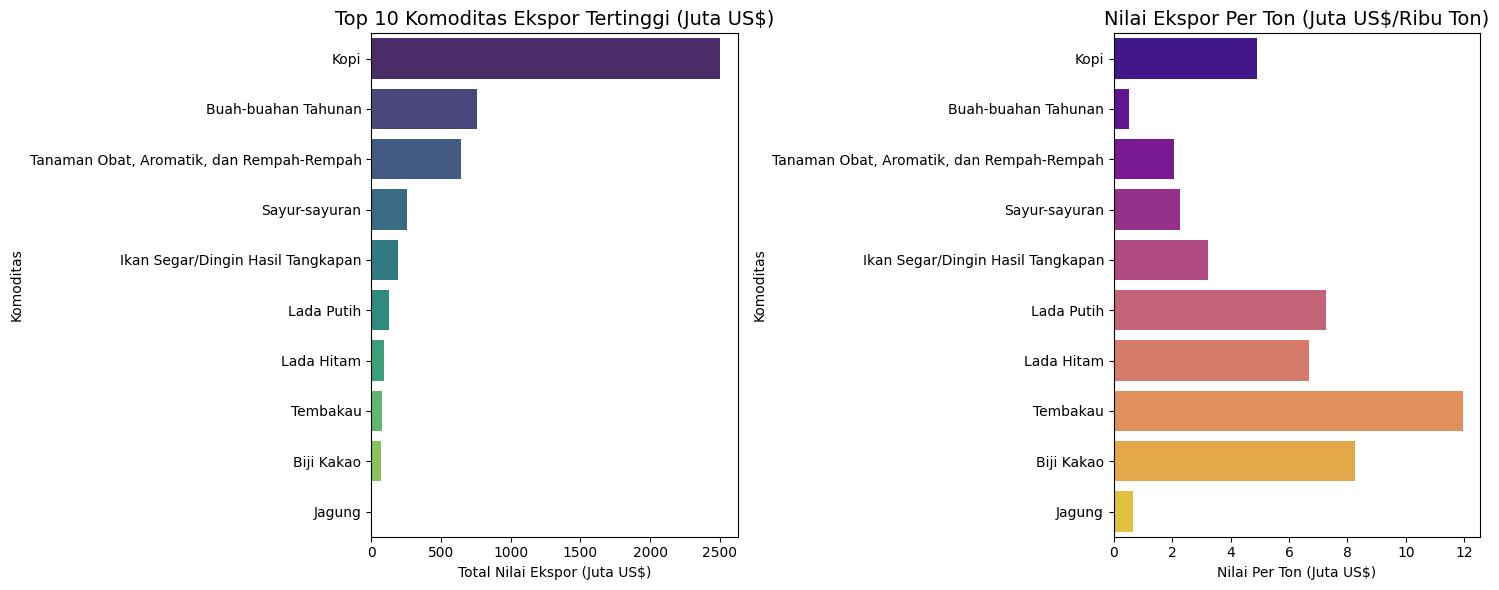

In [60]:
def identifikasi_komoditas_potensial(df_nilai, df_berat):
    """
    Mengidentifikasi komoditas dengan nilai ekspor tinggi
    """
    # Cari nama kolom komoditas
    komoditas_col_nilai = None
    for col in df_nilai.columns:
        if 'komoditas' in col.lower():
            komoditas_col_nilai = col
            break
    
    komoditas_col_berat = None
    for col in df_berat.columns:
        if 'komoditas' in col.lower():
            komoditas_col_berat = col
            break
    
    print(f"Kolom komoditas di df_nilai: '{komoditas_col_nilai}'")
    print(f"Kolom komoditas di df_berat: '{komoditas_col_berat}'")
    
    # Aggregate total per komoditas
    total_per_komoditas = df_nilai.groupby(komoditas_col_nilai)['Nilai_Ekspor_Juta_USD'].sum().reset_index()
    total_per_komoditas = total_per_komoditas.sort_values('Nilai_Ekspor_Juta_USD', ascending=False)
    
    # Tambahkan data berat
    berat_per_komoditas = df_berat.groupby(komoditas_col_berat)['Berat_Ekspor_Ribu_Ton'].sum().reset_index()
    total_per_komoditas = total_per_komoditas.merge(
        berat_per_komoditas, 
        left_on=komoditas_col_nilai, 
        right_on=komoditas_col_berat, 
        how='left'
    )
    
    # Rename kolom komoditas
    total_per_komoditas = total_per_komoditas.rename(columns={komoditas_col_nilai: 'Komoditas'})

    # Daftar komoditas yang dihapus (case insensitive)
    hapus_list = ['sarang burung', 'lainnya', 'jumlah']
    
    for item in hapus_list:
        total_per_komoditas = total_per_komoditas[
            ~total_per_komoditas['Komoditas'].str.lower().str.contains(item, na=False)
        ]
    
    print(f"Komoditas yang dihapus: {hapus_list}")
    
    # Hitung nilai per ton
    total_per_komoditas['Nilai_Per_Ton_Juta_USD'] = (
        total_per_komoditas['Nilai_Ekspor_Juta_USD'] / total_per_komoditas['Berat_Ekspor_Ribu_Ton']
    ).replace([np.inf, -np.inf], 0).fillna(0)
    
    return total_per_komoditas

komoditas_potensial = identifikasi_komoditas_potensial(
    df_ekspor_nilai_melted, 
    df_ekspor_berat_melted
)

print("\nTop 10 Komoditas Ekspor Potensial:")
display(komoditas_potensial.head(10))

# VISUALISASI KOMODITAS POTENSIAL
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 nilai ekspor
top10 = komoditas_potensial.head(10)
sns.barplot(data=top10, y='Komoditas', x='Nilai_Ekspor_Juta_USD', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Komoditas Ekspor Tertinggi (Juta US$)', fontsize=14)
axes[0].set_xlabel('Total Nilai Ekspor (Juta US$)')

# Nilai per ton
sns.barplot(data=top10, y='Komoditas', x='Nilai_Per_Ton_Juta_USD', ax=axes[1], palette='plasma')
axes[1].set_title('Nilai Ekspor Per Ton (Juta US$/Ribu Ton)', fontsize=14)
axes[1].set_xlabel('Nilai Per Ton (Juta US$)')

plt.tight_layout()
plt.show()

## 11. Identifikasi Komoditas Ekspor Potensial

Kolom komoditas di df_nilai: 'Komoditas'
Kolom komoditas di df_berat: 'Komoditas'

Top 10 Komoditas Ekspor Potensial (Tanpa Sarang Burung & Lainnya):


,Komoditas,Nilai_Ekspor_Juta_USD,Berat_Ekspor_Ribu_Ton,Nilai_Per_Ton_Juta_USD
0,Kopi,2501.9,508.9,4.916290
2,Buah-buahan Tahunan,759.8,1455.1,0.522163
3,"Tanaman Obat, Aromatik, dan Rempah-Rempah",642.3,312.3,2.056676
5,Sayur-sayuran,254.9,113.1,2.253758
6,Ikan Segar/Dingin Hasil Tangkapan,189.9,59.1,3.213198
8,Lada Putih,129.6,17.8,7.280899
9,Lada Hitam,92.7,13.9,6.669065
10,Tembakau,78.8,6.6,11.939394
11,Biji Kakao,71.1,8.6,8.267442
12,Jagung,5.1,7.8,0.653846


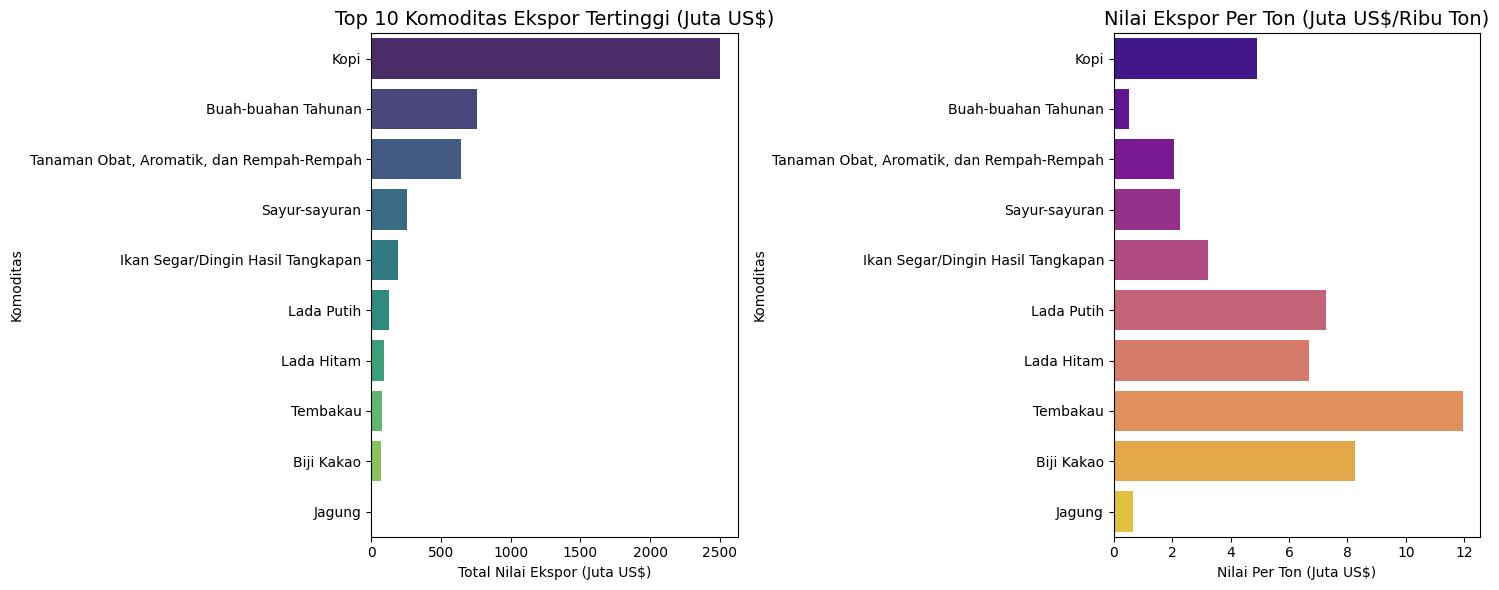

In [62]:
def identifikasi_komoditas_potensial(df_nilai, df_berat):
    """
    Mengidentifikasi komoditas dengan nilai ekspor tinggi
    """
    # Cari nama kolom komoditas
    komoditas_col_nilai = None
    for col in df_nilai.columns:
        if 'komoditas' in col.lower():
            komoditas_col_nilai = col
            break
    
    komoditas_col_berat = None
    for col in df_berat.columns:
        if 'komoditas' in col.lower():
            komoditas_col_berat = col
            break
    
    print(f"Kolom komoditas di df_nilai: '{komoditas_col_nilai}'")
    print(f"Kolom komoditas di df_berat: '{komoditas_col_berat}'")
    
    # Aggregate total per komoditas
    total_per_komoditas = df_nilai.groupby(komoditas_col_nilai)['Nilai_Ekspor_Juta_USD'].sum().reset_index()
    total_per_komoditas = total_per_komoditas.sort_values('Nilai_Ekspor_Juta_USD', ascending=False)
    
    # Tambahkan data berat
    berat_per_komoditas = df_berat.groupby(komoditas_col_berat)['Berat_Ekspor_Ribu_Ton'].sum().reset_index()
    total_per_komoditas = total_per_komoditas.merge(
        berat_per_komoditas, 
        left_on=komoditas_col_nilai, 
        right_on=komoditas_col_berat, 
        how='left'
    )
    
    # Rename kolom komoditas
    total_per_komoditas = total_per_komoditas.rename(columns={komoditas_col_nilai: 'Komoditas'})

    # Hapus komoditas yang tidak diinginkan
    hapus_list = ['sarang burung', 'lainnya', 'jumlah']
    for item in hapus_list:
        total_per_komoditas = total_per_komoditas[
            ~total_per_komoditas['Komoditas'].str.lower().str.contains(item, na=False)
        ]
    
    # Hitung nilai per ton
    total_per_komoditas['Nilai_Per_Ton_Juta_USD'] = (
        total_per_komoditas['Nilai_Ekspor_Juta_USD'] / total_per_komoditas['Berat_Ekspor_Ribu_Ton']
    ).replace([np.inf, -np.inf], 0).fillna(0)
    
    return total_per_komoditas

komoditas_potensial = identifikasi_komoditas_potensial(
    df_ekspor_nilai_melted, 
    df_ekspor_berat_melted
)

print("\nTop 10 Komoditas Ekspor Potensial (Tanpa Sarang Burung & Lainnya):")
display(komoditas_potensial.head(10))

# VISUALISASI KOMODITAS POTENSIAL
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 nilai ekspor
top10 = komoditas_potensial.head(10)
sns.barplot(data=top10, y='Komoditas', x='Nilai_Ekspor_Juta_USD', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Komoditas Ekspor Tertinggi (Juta US$)', fontsize=14)
axes[0].set_xlabel('Total Nilai Ekspor (Juta US$)')

# Nilai per ton
sns.barplot(data=top10, y='Komoditas', x='Nilai_Per_Ton_Juta_USD', ax=axes[1], palette='plasma')
axes[1].set_title('Nilai Ekspor Per Ton (Juta US$/Ribu Ton)', fontsize=14)
axes[1].set_xlabel('Nilai Per Ton (Juta US$)')

plt.tight_layout()
plt.show()

## 12. Feature Engineering - Indeks Ketahanan Pangan

Cek Data Produksi Sayuran (Clean):


,Provinsi,Produksi Bawang Merah (kuintal) (Kw),Produksi Bayam (kuintal) (Kw),Produksi Cabai Rawit (kuintal) (Kw),Produksi Kacang Panjang (kuintal) (Kw),Produksi Kangkung (kuintal) (Kw),Produksi Labu Siam (kuintal) (Kw),Produksi Melon (kuintal) (Kw),Produksi Petsai/Sawi (kuintal) (Kw),Produksi Terung (kuintal) (Kw),Produksi Tomat (kuintal) (Kw),Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),Produksi Cabai Keriting(kuintal) (Kw)
10,DKI Jakarta,52.73,24522.03,421.93,0.23,31918.84,64,7.9,19158.71,528.39,29.97,0.32,0.66
11,Jawa Barat,1994154.01,372798.98,1987916.59,666031.83,683886.87,910961.36,10804.07,1498030.17,1188275.45,2684310.69,1372168.21,2217330.71
12,Jawa Tengah,5840345.01,161035.00,2663050.62,181843.57,345352.28,1034344.6,220861.69,971342.68,576275.90,1130126.19,501228.63,1673982.71
13,DI Yogyakarta,267186.01,31826.38,250299.13,17371.14,58719.00,200.05,66638.7,33900.58,28246.81,6677.60,28075.18,451717.72
14,Jawa Timur,5003012.27,148956.38,6037178.26,312706.03,331999.52,788540.88,605492.8,833208.09,941809.95,1268102.30,1045356.44,356646.68



Cek Data Padi Aggregate:


,Provinsi,Bulan,Produksi_Padi_Ton,Bulan_Num,Luas_Panen_Ha,Produktivitas_Ton_per_Ha
0,DKI JAKARTA,Januari,112.87,1,24.39,4.627716
1,JAWA BARAT,Januari,362854.42,1,62186.39,5.834949
2,JAWA TENGAH,Januari,194648.97,1,34906.46,5.576302
3,DI YOGYAKARTA,Januari,35465.86,1,6303.13,5.626706
4,JAWA TIMUR,Januari,384669.75,1,66160.11,5.814225


Provinsi di df_padi: ['DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR', 'BANTEN']
Provinsi di df_sayuran: ['DKI JAKARTA', 'JAWA BARAT', 'JAWA TENGAH', 'DI YOGYAKARTA', 'JAWA TIMUR', 'BANTEN']
Total kolom sayuran: 12
Data Sayuran (Jumlah Komoditas per Provinsi):


,Provinsi,Jumlah_Komoditas
0,DKI JAKARTA,9
1,JAWA BARAT,9
2,JAWA TENGAH,9
3,DI YOGYAKARTA,9
4,JAWA TIMUR,9
5,BANTEN,9


Hasil Merge:


,Provinsi,Produksi_Padi_Ton,Luas_Panen_Ha,Produktivitas_Ton_per_Ha,Jumlah_Komoditas
0,BANTEN,1774016.87,345420.54,5.091394,9
1,DI YOGYAKARTA,547510.10,107224.23,5.186487,9
2,DKI JAKARTA,1487.45,273.54,4.462150,9
3,JAWA BARAT,10226653.75,1755300.21,5.832003,9
4,JAWA TENGAH,9304062.84,1674994.13,5.566423,9
5,JAWA TIMUR,10438360.58,1841346.29,5.698565,9



Indeks Ketahanan Pangan per Provinsi:


,Provinsi,Produksi_Padi_Ton,Luas_Panen_Ha,Produktivitas_Ton_per_Ha,Jumlah_Komoditas,Produksi_Padi_Ton_Index,Produktivitas_Ton_per_Ha_Index,Jumlah_Komoditas_Index,Indeks_Ketahanan_Pangan,Tingkat_Ketahanan
0,BANTEN,1774016.87,345420.54,5.091394,9,0.169833,0.459352,0.5,0.376395,Rendah
1,DI YOGYAKARTA,547510.10,107224.23,5.186487,9,0.052317,0.528770,0.5,0.360362,Rendah
2,DKI JAKARTA,1487.45,273.54,4.462150,9,0.000000,0.000000,0.5,0.166667,Sangat Rendah
3,JAWA BARAT,10226653.75,1755300.21,5.832003,9,0.979715,1.000000,0.5,0.826572,Tinggi
4,JAWA TENGAH,9304062.84,1674994.13,5.566423,9,0.891318,0.806125,0.5,0.732481,Sedang
5,JAWA TIMUR,10438360.58,1841346.29,5.698565,9,1.000000,0.902589,0.5,0.800863,Tinggi


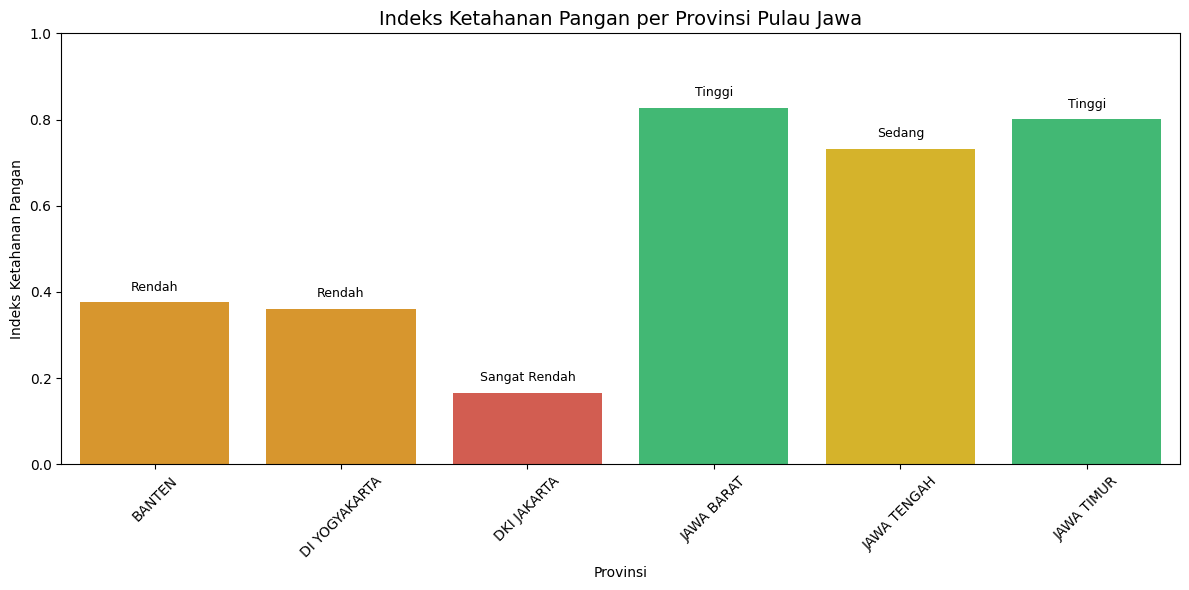

In [63]:
def calculate_food_security_index(df_padi, df_sayuran):
    """
    Menghitung indeks ketahanan pangan berdasarkan 3 faktor:
    1. Ketersediaan (Produktivitas)
    2. Akses (Keragaman komoditas)
    3. Stabilitas (Konsistensi produksi)
    """
    df_padi = df_padi.copy()
    df_sayuran = df_sayuran.copy()
    
    # Standardisasi nama provinsi (upper case, trim spasi)
    df_padi['Provinsi'] = df_padi['Provinsi'].str.upper().str.strip()
    df_sayuran['Provinsi'] = df_sayuran['Provinsi'].str.upper().str.strip()
    
    print("Provinsi di df_padi:", df_padi['Provinsi'].unique().tolist())
    print("Provinsi di df_sayuran:", df_sayuran['Provinsi'].unique().tolist())
    
    # Agregasi data padi per provinsi
    padi_agg = df_padi.groupby('Provinsi').agg({
        'Produksi_Padi_Ton': 'sum',
        'Luas_Panen_Ha': 'sum',
        'Produktivitas_Ton_per_Ha': 'mean'
    }).reset_index()
    
    # Cek kolom sayuran (selain Provinsi)
    sayuran_cols = [col for col in df_sayuran.columns if col != 'Provinsi']
    print(f"Total kolom sayuran: {len(sayuran_cols)}")
    
    # Hitung jumlah komoditas dengan produksi > 0
    sayuran_numeric = df_sayuran[sayuran_cols].select_dtypes(include=['float64', 'int64'])
    jumlah_komoditas = (sayuran_numeric > 0).sum(axis=1)
    
    sayuran_df = pd.DataFrame({
        'Provinsi': df_sayuran['Provinsi'].values,
        'Jumlah_Komoditas': jumlah_komoditas.values
    })
    
    print("Data Sayuran (Jumlah Komoditas per Provinsi):")
    display(sayuran_df)
    
    # Merge
    security_df = padi_agg.merge(sayuran_df, on='Provinsi', how='left')
    
    # Isi NaN dengan 0
    security_df['Jumlah_Komoditas'] = security_df['Jumlah_Komoditas'].fillna(0)
    
    print("Hasil Merge:")
    display(security_df)
    
    # Normalisasi min-max scaling
    for col in ['Produksi_Padi_Ton', 'Produktivitas_Ton_per_Ha', 'Jumlah_Komoditas']:
        min_val = security_df[col].min()
        max_val = security_df[col].max()
        
        if max_val - min_val > 0:
            security_df[f'{col}_Index'] = (security_df[col] - min_val) / (max_val - min_val)
        else:
            security_df[f'{col}_Index'] = 0.5
    
    # Indeks ketahanan pangan
    security_df['Indeks_Ketahanan_Pangan'] = security_df[
        ['Produksi_Padi_Ton_Index', 'Produktivitas_Ton_per_Ha_Index', 'Jumlah_Komoditas_Index']
    ].mean(axis=1)
    
    # Klasifikasi tingkat ketahanan pangan
    security_df['Tingkat_Ketahanan'] = pd.cut(
        security_df['Indeks_Ketahanan_Pangan'],
        bins=[0, 0.25, 0.5, 0.75, 1.01],
        labels=['Sangat Rendah', 'Rendah', 'Sedang', 'Tinggi'],
        right=False
    )
    
    return security_df

print("Cek Data Produksi Sayuran (Clean):")
display(df_produksi_sayuran_clean.head())

print("\nCek Data Padi Aggregate:")
display(df_padi_aggregate.head())

# Hitung indeks ketahanan pangan
df_ketahanan_pangan = calculate_food_security_index(
    df_padi_aggregate, 
    df_produksi_sayuran_clean
)

print("\nIndeks Ketahanan Pangan per Provinsi:")
display(df_ketahanan_pangan)

# VISUALISASI INDEKS KETAHANAN PANGAN
plt.figure(figsize=(12, 6))

# Buat palette warna manual
colors = {'Sangat Rendah': '#e74c3c', 'Rendah': '#f39c12', 
          'Sedang': '#f1c40f', 'Tinggi': '#2ecc71'}

sns.barplot(
    data=df_ketahanan_pangan, 
    x='Provinsi', 
    y='Indeks_Ketahanan_Pangan', 
    hue='Tingkat_Ketahanan',
    palette=colors,
    dodge=False
)

plt.title('Indeks Ketahanan Pangan per Provinsi Pulau Jawa', fontsize=14)
plt.xlabel('Provinsi')
plt.ylabel('Indeks Ketahanan Pangan')
plt.xticks(rotation=45)
plt.ylim(0, 1)

# Tambahkan label tingkat ketahanan di atas bar
for i, row in df_ketahanan_pangan.iterrows():
    plt.text(i, row['Indeks_Ketahanan_Pangan'] + 0.02, 
             row['Tingkat_Ketahanan'], ha='center', va='bottom', fontsize=9)

# Hapus legend karena sudah ada label
plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

## 13. Data Preparation untuk Machine Learning

In [72]:
# =====================================================
# 19. PREPARE DATA MACHINE LEARNING (FINAL)
# =====================================================

def prepare_ml_data(df_security, df_ekspor, df_sayuran):
    """
    Menyiapkan data untuk model machine learning
    """
    df_ekspor = df_ekspor.copy()
    
    komoditas_col = None
    for col in df_ekspor.columns:
        if 'komoditas' in col.lower():
            komoditas_col = col
            break
    
    hapus_list = ['sarang burung', 'lainnya', 'jumlah']
    for item in hapus_list:
        df_ekspor = df_ekspor[
            ~df_ekspor[komoditas_col].astype(str).str.lower().str.contains(item, na=False)
        ]
    
    print(f"Komoditas yang dihapus: {hapus_list}")
    print(f"Sisa data ekspor: {len(df_ekspor)} baris")
    
    # 1. Data ekspor aggregate
    ekspor_agg = df_ekspor.groupby(komoditas_col)['Nilai_Ekspor_Juta_USD'].sum().reset_index()
    ekspor_agg = ekspor_agg.rename(columns={komoditas_col: 'Komoditas'})
    ekspor_agg = ekspor_agg.sort_values('Nilai_Ekspor_Juta_USD', ascending=False)
    
    print("Top 5 Komoditas Ekspor (Setelah Filter):")
    display(ekspor_agg.head(5))
    
    # 2. Data sayuran per provinsi
    df_sayuran = df_sayuran.copy()
    df_sayuran['Provinsi'] = df_sayuran['Provinsi'].str.upper().str.strip()
    
    # Filter provinsi Jawa
    df_sayuran_jawa = df_sayuran[df_sayuran['Provinsi'].isin(provinsi_jawa)]
    print(f"Data sayuran untuk provinsi Jawa: {len(df_sayuran_jawa)} baris")
    
    # Set index
    sayuran_prov = df_sayuran_jawa.set_index('Provinsi')
    
    # 3. Standardisasi df_security
    df_security = df_security.copy()
    df_security['Provinsi'] = df_security['Provinsi'].str.upper().str.strip()
    df_security_jawa = df_security[df_security['Provinsi'].isin(provinsi_jawa)]
    
    # 4. Buat ML data
    ml_data = df_security_jawa[['Provinsi', 'Indeks_Ketahanan_Pangan', 'Jumlah_Komoditas']].copy()
    
    # 5. Kolom Produksi Sayuran
    # Ambil semua kolom yang mengandung kata 'Produksi'
    kolom_sayuran = [col for col in sayuran_prov.columns if 'Produksi' in col]
    
    print(f"Total kolom produksi sayuran: {len(kolom_sayuran)}")
    print(f"Kolom produksi: {kolom_sayuran}")
    
    # Tambahkan semua kolom produksi ke ML data
    for komoditas in kolom_sayuran:
        values = []
        for prov in ml_data['Provinsi']:
            if prov in sayuran_prov.index:
                val = sayuran_prov.loc[prov, komoditas]
                if pd.isna(val):
                    val = 0
                values.append(val)
            else:
                values.append(0)
        ml_data[f'{komoditas}'] = values
    
    # 6. Tambahkan fitur ekspor
    ml_data['Total_Ekspor_Potensial'] = ekspor_agg['Nilai_Ekspor_Juta_USD'].sum()
    
    # 7. Target: Potensi Ekspor
    # 1 = Provinsi berpotensi ekspor tinggi (Indeks Ketahanan Pangan > Median)
    # 0 = Provinsi berpotensi ekspor rendah (Indeks Ketahanan Pangan <= Median)
    median_ketahanan = ml_data['Indeks_Ketahanan_Pangan'].median()
    ml_data['Potensi_Ekspor'] = (ml_data['Indeks_Ketahanan_Pangan'] > median_ketahanan).astype(int)
    
    print(f"Median Indeks Ketahanan: {median_ketahanan:.4f}")
    print("Distribusi Target Potensi_Ekspor (1 = Potensi Tinggi, 0 = Potensi Rendah):")
    print(ml_data['Potensi_Ekspor'].value_counts())
    
    return ml_data

print("Cek df_ekspor_nilai_melted:")
display(df_ekspor_nilai_melted.head())

# Prepare data ML
ml_data = prepare_ml_data(
    df_ketahanan_pangan, 
    df_ekspor_nilai_melted, 
    df_produksi_sayuran_clean
)

print("\nData untuk Machine Learning:")
display(ml_data)

Cek df_ekspor_nilai_melted:


,Komoditas,Bulan,Nilai_Ekspor_Juta_USD,Bulan_Num
7,Biji Kakao,Januari,6.6,1
21,Biji Kakao,Februari,8.0,2
35,Biji Kakao,Maret,4.7,3
49,Biji Kakao,April,8.2,4
63,Biji Kakao,Mei,8.4,5


Komoditas yang dihapus: ['sarang burung', 'lainnya', 'jumlah']
Sisa data ekspor: 120 baris
Top 5 Komoditas Ekspor (Setelah Filter):


,Komoditas,Nilai_Ekspor_Juta_USD
4,Kopi,2501.9
1,Buah-buahan Tahunan,759.8
8,"Tanaman Obat, Aromatik, dan Rempah-Rempah",642.3
7,Sayur-sayuran,254.9
2,Ikan Segar/Dingin Hasil Tangkapan,189.9


Data sayuran untuk provinsi Jawa: 6 baris
Total kolom produksi sayuran: 12
Kolom produksi: ['Produksi Bawang Merah (kuintal) (Kw)', 'Produksi Bayam (kuintal) (Kw)', 'Produksi Cabai Rawit (kuintal) (Kw)', 'Produksi Kacang Panjang (kuintal) (Kw)', 'Produksi Kangkung (kuintal) (Kw)', 'Produksi Labu Siam (kuintal) (Kw)', 'Produksi Melon (kuintal) (Kw)', 'Produksi Petsai/Sawi (kuintal) (Kw)', 'Produksi Terung (kuintal) (Kw)', 'Produksi Tomat (kuintal) (Kw)', 'Produksi Cabai Besar/TW/Teropong (kuintal) (Kw)', 'Produksi Cabai Keriting(kuintal) (Kw)']
Median Indeks Ketahanan: 0.5544
Distribusi Target Potensi_Ekspor (1 = Potensi Tinggi, 0 = Potensi Rendah):
Potensi_Ekspor
0    3
1    3
Name: count, dtype: int64

Data untuk Machine Learning:


,Provinsi,Indeks_Ketahanan_Pangan,Jumlah_Komoditas,Produksi Bawang Merah (kuintal) (Kw),Produksi Bayam (kuintal) (Kw),Produksi Cabai Rawit (kuintal) (Kw),Produksi Kacang Panjang (kuintal) (Kw),Produksi Kangkung (kuintal) (Kw),Produksi Labu Siam (kuintal) (Kw),Produksi Melon (kuintal) (Kw),Produksi Petsai/Sawi (kuintal) (Kw),Produksi Terung (kuintal) (Kw),Produksi Tomat (kuintal) (Kw),Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),Produksi Cabai Keriting(kuintal) (Kw),Total_Ekspor_Potensial,Potensi_Ekspor
0,BANTEN,0.376395,9,13950.76,76425.13,76213.37,40099.30,105529.12,1130.50,2576.60,86815.48,16435.72,4963.71,3213.32,75215.63,4726.1,0
1,DI YOGYAKARTA,0.360362,9,267186.01,31826.38,250299.13,17371.14,58719.00,200.05,66638.70,33900.58,28246.81,6677.60,28075.18,451717.72,4726.1,0
2,DKI JAKARTA,0.166667,9,52.73,24522.03,421.93,0.23,31918.84,64.00,7.90,19158.71,528.39,29.97,0.32,0.66,4726.1,0
3,JAWA BARAT,0.826572,9,1994154.01,372798.98,1987916.59,666031.83,683886.87,910961.36,10804.07,1498030.17,1188275.45,2684310.69,1372168.21,2217330.71,4726.1,1
4,JAWA TENGAH,0.732481,9,5840345.01,161035.00,2663050.62,181843.57,345352.28,1034344.60,220861.69,971342.68,576275.90,1130126.19,501228.63,1673982.71,4726.1,1
5,JAWA TIMUR,0.800863,9,5003012.27,148956.38,6037178.26,312706.03,331999.52,788540.88,605492.80,833208.09,941809.95,1268102.30,1045356.44,356646.68,4726.1,1


## 14. Model Machine Learning - Random Forest


RANDOM FOREST CLASSIFICATION REPORT
Training Accuracy: 1.0000
Testing Accuracy: 1.0000

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2


Top 10 Feature Importance:


,Feature,Importance
4,Produksi Cabai Rawit (kuintal) (Kw),0.112903
10,Produksi Terung (kuintal) (Kw),0.112903
3,Produksi Bayam (kuintal) (Kw),0.096774
8,Produksi Melon (kuintal) (Kw),0.096774
13,Produksi Cabai Keriting(kuintal) (Kw),0.080645
6,Produksi Kangkung (kuintal) (Kw),0.080645
0,Indeks_Ketahanan_Pangan,0.080645
12,Produksi Cabai Besar/TW/Teropong (kuintal) (Kw),0.080645
7,Produksi Labu Siam (kuintal) (Kw),0.064516
2,Produksi Bawang Merah (kuintal) (Kw),0.048387


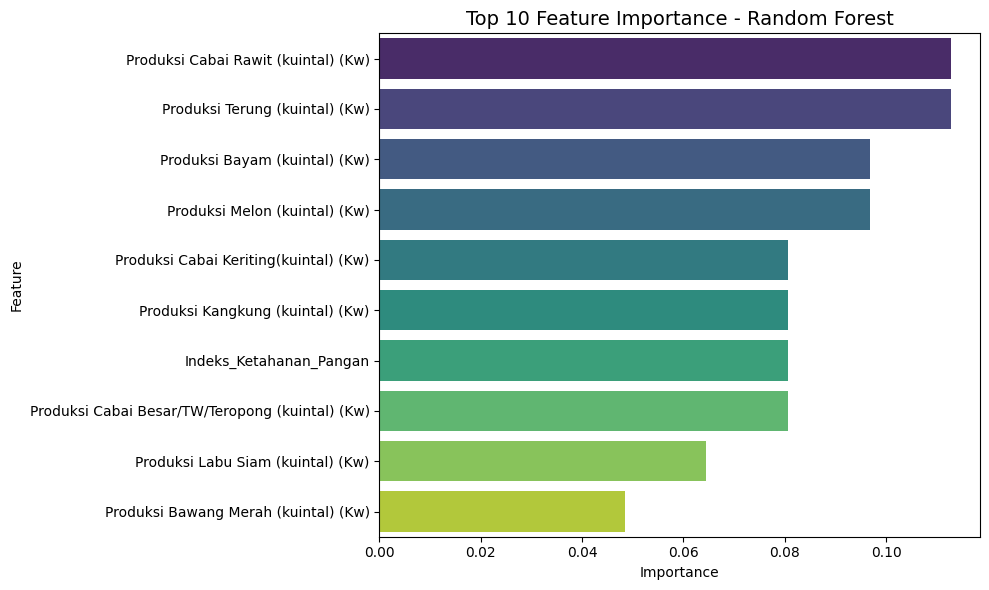

In [73]:
def train_random_forest(df_ml, target_col='Potensi_Ekspor'):
    """
    Melatih model Random Forest untuk klasifikasi potensi ekspor
    """
    # Split features dan target
    X = df_ml.drop(columns=[target_col, 'Provinsi'])
    y = df_ml[target_col]
    
    # Handle missing values dan infinite values
    X = X.replace([np.inf, -np.inf], 0).fillna(0)
    
    # Pastikan semua data numerik
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors='coerce').fillna(0)
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train model
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )
    rf_model.fit(X_train, y_train)
    
    # Predictions
    y_pred = rf_model.predict(X_test)
    y_pred_train = rf_model.predict(X_train)
    
    # Metrics
    print("\n" + "="*60)
    print("RANDOM FOREST CLASSIFICATION REPORT")
    print("="*60)
    print(f"Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
    print(f"Testing Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_pred))
    
    # Feature Importance
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nTop 10 Feature Importance:")
    display(feature_importance.head(10))
    
    return rf_model, feature_importance

# Train Random Forest
rf_model, rf_importance = train_random_forest(ml_data)

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importance - Random Forest', fontsize=14)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()